In [1]:
import netket as nk
import numpy as np
import matplotlib.pyplot as plt
import json
from pyscf import gto, scf, fci
import netket.experimental as nkx

# 设置H2分子的几何构型
bond_length = 1.0  # H2平衡键长（埃）
geometry = [
    ('H', (0., 0., 0.)),
    ('H', (bond_length, 0., 0.)),
]

# 创建分子对象，使用STO-3G基组
mol = gto.M(atom=geometry, basis='STO-3G')

# 进行Hartree-Fock计算
mf = scf.RHF(mol).run(verbose=0)
E_hf = mf.e_tot
print(f"Hartree-Fock能量: {E_hf:.8f} Ha")

# 进行FCI计算作为参考
cisolver = fci.FCI(mf)
E_fci, fcivec = cisolver.kernel()
print(f"FCI能量: {E_fci:.8f} Ha")

# 使用NetKet创建哈密顿量
ha = nkx.operator.from_pyscf_molecule(mol)

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Hartree-Fock能量: -1.06610865 Ha
FCI能量: -1.10115033 Ha


In [2]:
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals=2,  # 总空间轨道数
    s = 1/2,
    n_fermions_per_spin=(1, 1)  # 每种自旋的电子数
)

# 创建采样器 - 使用费米子跳跃采样器
# 对于分子系统，我们使用完整的轨道图（完全连接）
cluster = [(0,1),(2,3)]
#

# g = nk.graph.Graph(edges=[(0,2),(1,3),(2,0),(3,1)])
g = nk.graph.Graph(edges=[(0,1),(2,3)])
# g = nk.graph.Graph(edges=cluster)
sa = nk.sampler.MetropolisFermionHop(
    hi, graph=g, n_chains=16, spin_symmetric=True, sweep_size=64
)

In [3]:
import jax
import jax.numpy as jnp


# Note: This function can also be found inside of netket, in `nk.jax.logdet_cmplx`, but we implement it here
# for pedagogical purposes.
def _logdet_cmplx(A):
    sign, logabsdet = jnp.linalg.slogdet(A)
    return logabsdet.astype(complex) + jnp.log(sign.astype(complex))

In [4]:
from flax import nnx
from jax.nn.initializers import lecun_normal
from typing import Any
from functools import partial

DType = Any
default_kernel_init = lecun_normal()


class LogSlaterDeterminant(nnx.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions

    def __init__(
        self,
        hilbert,
        kernel_init=default_kernel_init,
        param_dtype=float,
        *,
        rngs: nnx.Rngs,
    ):
        self.hilbert = hilbert

        # To generate random numbers we need to extract the key from the `rngs` object.
        key = rngs.params()

        # the N x Nf matrix of the orbitals
        self.M = nnx.Param(
            kernel_init(
                key,
                (
                    self.hilbert.n_orbitals,
                    self.hilbert.n_fermions,
                ),
                param_dtype,
            )
        )

    def __call__(self, n: jax.Array) -> jax.Array:
        # For simplicity, we write a function that operates on a single configuration of size (N,)
        # and we vectorize it using `jnp.vectorize` with the signature='(n)->()' argument, which specifies
        # that the function is defined to operate on arrays of shape (n,) and return scalars.
        @partial(jnp.vectorize, signature="(n)->()")
        def log_sd(n):
            # Find the positions of the occupied orbitals
            R = n.nonzero(size=self.hilbert.n_fermions)[0]

            # Extract from the (N, Nf) matrix the (Nf, Nf) submatrix of M corresponding to the occupied orbitals.
            A = self.M[R]

            return _logdet_cmplx(A)

        return log_sd(n)

In [6]:
# Create the Slater determinant model, using the seed 0
model = LogSlaterDeterminant(hi, rngs=nnx.Rngs(0))

# Define the Metropolis-Hastings sampler
vs = nk.vqs.MCState(sa, model, n_discard_per_chain=10, n_samples=512)
# 设置优化器
opt = nk.optimizer.Sgd(learning_rate=0.05)
sr = nk.optimizer.SR(diag_shift=0.01)

# 创建VMC驱动器
gs = nk.driver.VMC(ha, opt, variational_state=vs, preconditioner=sr)

# 运行优化
exp_name = "h2_molecule_slater"

In [7]:
gs.run(300, out=exp_name)

100%|██████████| 300/300 [00:05<00:00, 58.16it/s, Energy=-0.805+0.000j ± 0.011 [σ²=0.067, R̂=1.0224]]


(JsonLog('h2_molecule_slater', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    0.024619579315185547
   	Params: 0.023526430130004883,)

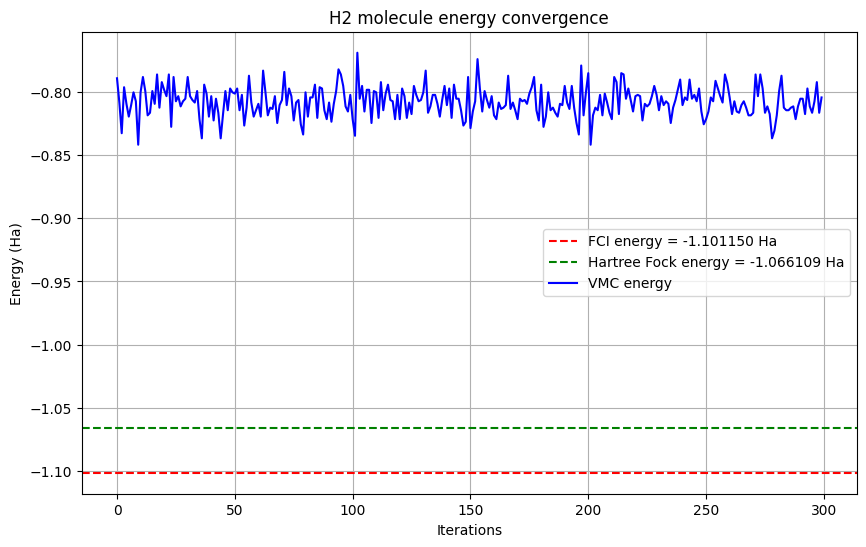


最终VMC能量: -0.80456547 Ha
与FCI能量误差: 0.29658486 Ha


In [9]:
############## 绘图 #################
# 获取精确对角化能量（FCI能量）
ed_energies = np.array([E_fci])  # H2只有一个基态能量

# 读取日志数据
with open(f"{exp_name}.log") as f:
    data = json.load(f)

x = data["Energy"]["iters"]
y = data["Energy"]["Mean"]['real']

# 绘制能量收敛曲线
plt.figure(figsize=(10, 6))
plt.axhline(ed_energies[0], color="red", linestyle="--", label=f"FCI energy = {E_fci:.6f} Ha")
plt.axhline(E_hf, color="green", linestyle="--", label=f"Hartree Fock energy = {E_hf:.6f} Ha")
plt.plot(x, y, 'b-', label="VMC energy")
plt.xlabel("Iterations")
plt.ylabel("Energy (Ha)")
plt.title("H2 molecule energy convergence")
plt.legend()
plt.grid(True)
plt.show()

# 打印最终结果
print(f"\n最终VMC能量: {y[-1]:.8f} Ha")
print(f"与FCI能量误差: {abs(y[-1] - E_fci):.8f} Ha")
